In [ ]:
from google.colab import  drive
drive.mount('/drive')

Mounted at /drive


In [ ]:
import json
import re
import os
import json
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

In [ ]:
def search_entity(sentence):
    e1_matches = re.findall(r'<e1>(.*)</e1>', sentence)
    e2_matches = re.findall(r'<e2>(.*)</e2>', sentence)

    if not e1_matches or not e2_matches:
        # Return None to indicate that the sentence should be skipped
        return None

    e1 = e1_matches[0]
    e2 = e2_matches[0]

    sentence = sentence.replace('<e1>' + e1 + '</e1>', ' <e1> ' + e1 + ' </e1> ', 1)
    sentence = sentence.replace('<e2>' + e2 + '</e2>', ' <e2> ' + e2 + ' </e2> ', 1)
    sentence = sentence.split()
    sentence = ' '.join(sentence)
    sentence = sentence.replace('< e1 >', '<e1>')
    sentence = sentence.replace('< e2 >', '<e2>')
    sentence = sentence.replace('< /e1 >', '</e1>')
    sentence = sentence.replace('< /e2 >', '</e2>')
    sentence = sentence.split()

    assert '<e1>' in sentence
    assert '<e2>' in sentence
    assert '</e1>' in sentence
    assert '</e2>' in sentence

    return sentence


def convert(path_src, path_des):
    with open(path_src, 'r', encoding='utf-8') as fr:
        data = fr.readlines()

    with open(path_des, 'w', encoding='utf-8') as fw:
        for i in range(0, len(data), 3):
            id_s, sentence = data[i].strip().split('  ')
            sentence = sentence[1:-1]

            # Process sentence using search_entity function
            sentence = search_entity(sentence)

            # Check if search_entity returned None
            if sentence is None:
                # Skip processing
                continue

            # Create a dictionary with metadata
            meta = dict(
                id=id_s,
                relation=data[i+1].strip(),
                sentence=sentence,
                comment=data[i+2].strip()
            )

            # Write the dictionary as a JSON object
            json.dump(meta, fw, ensure_ascii=False)

            fw.write('\n')


# Load Data

In [ ]:
#my_path = "/drive/MyDrive/datasets/relations_extraction/dnrti_re/"
my_path = "/drive/MyDrive/datasets/relations_extraction/dnrti_aug_re/"

In [ ]:
# path_train = my_path + 'pre_train2.txt'
# path_test = my_path +'pre_test2.txt'
# path_valid = my_path +'pre_test2.txt'

# # # path_train = my_path + 'pre_train.txt'
# # # convert(path_train, my_path + '/pre_train1.json')

# convert(path_train, my_path + '/train1.json')
# convert(path_test, my_path +'/test1.json')
# convert(path_test, my_path +'/valid1.json')

# Embeddings

In [ ]:
def load_embedding(embd_path , word_dim = 300):
    word2id = dict()
    word_vec = list()

    word2id['PAD'] = len(word2id)
    word2id['UNK'] = len(word2id)
    word2id['<e1>'] = len(word2id)
    word2id['<e2>'] = len(word2id)
    word2id['</e1>'] = len(word2id)
    word2id['</e2>'] = len(word2id)

    with open(embd_path, 'r', encoding='utf-8') as fr:
        for line in fr:
            line = line.strip().split()
            if len(line) != word_dim + 1:
                continue
            word2id[line[0]] = len(word2id)
            word_vec.append(np.asarray(line[1:], dtype=np.float32))

    word_vec = np.stack(word_vec)
    vec_mean, vec_std = word_vec.mean(), word_vec.std()
    special_emb = np.random.normal(vec_mean, vec_std, (6, word_dim))
    special_emb[0] = 0  # <pad> est initialisé à zéro

    word_vec = np.concatenate((special_emb, word_vec), axis=0)
    word_vec = word_vec.astype(np.float32).reshape(-1, word_dim)
    word_vec = torch.from_numpy(word_vec)
    return word2id, word_vec

In [ ]:
embd_path = "/drive/MyDrive/datasets/embeddings/glove_6B_300d/glove.6B.300d.txt"
word2id, word_vec = load_embedding(embd_path , word_dim = 300)

In [ ]:
import os

def create_relation_file(relations, data_dir=my_path):
    relation_file = os.path.join(data_dir, 'relation2id.txt')

    # Create a mapping between relations and IDs
    rel2id = {rel: str(idx) for idx, rel in enumerate(relations)}

    # Create the reverse mapping (ID to relation)
    id2rel = {str(idx): rel for idx, rel in enumerate(relations)}

    # Write the mapping to the relation2id.txt file
    with open(relation_file, 'w', encoding='utf-8') as fw:
        for rel, rel_id in rel2id.items():
            fw.write(f"{rel}\t{rel_id}\n")

    return rel2id, id2rel


In [ ]:
# unique_relations = ['targetedBy(e1,e2)', 'locatedAt(e1,e2)', 'associatedWith(e1,e2)',
#                     'targets(e1,e2)', 'employs(e1,e2)', 'originatesFrom(e1,e2)',
#                     'usedBy(e1,e2)', 'contains(e1,e2)', 'relatedTo(e1,e2)',
#                     'identifies(e1,e2)', 'monitors(e1,e2)', 'usesTool(e1,e2)',
#                     'employedBy(e1,e2)', 'hasAttackTime(e1,e2)', 'deploys(e1,e2)',
#                     'aimsFor(e1,e2)', 'monitoredBy(e1,e2)', 'motivates(e1,e2)',
#                     'shapes(e1,e2)', 'hasCharacteristics(e1,e2)', 'analyses(e1,e2)']

# unique_relations = ['<PAD>', 'targets(e1,e2)', 'usesTool(e1,e2)', 'targetedBy(e1,e2)',
#                     'originatesFrom(e1,e2)', 'locatedAt(e1,e2)',
#                     'associatedWith(e1,e2)', 'employs(e1,e2)', 'usedBy(e1,e2)',
#                     'usesFile(e1,e2)', 'contains(e1,e2)', 'hasCharacteristics(e1,e2)',
#                     'relatedTo(e1,e2)', 'affiliatedWith(e1,e2)',
#                     'hasAttackTime(e1,e2)', 'identifies(e1,e2)', 'monitors(e1,e2)',
#                     'deploys(e1,e2)', 'employedBy(e1,e2)', 'identifiedBy(e1,e2)',
#                     'aimsFor(e1,e2)', 'monitoredBy(e1,e2)', 'motivates(e1,e2)',
#                     'shapes(e1,e2)', 'analyses(e1,e2)']

#extended dnrti adhering to STIX format
# unique_relations = ['uses(e1,e2)', 'associatedwith(e1,e2)','executes(e1,e2)','targets(e1,e2)', 'hasattacklocation(e1,e2)','compromises(e1,e2)',
#     'targetedby(e1,e2)', 'hosts(e1,e2)','haslocation(e1,e2)','monitors(e1,e2)','hasattacktime(e1,e2)', 'affiliatedwith(e1,e2)','exploits(e1,e2)',
#     'identifies(e1,e2)', 'executedby(e1,e2)','usedby(e1,e2)', 'hasvulnerability(e1,e2)', 'embeddedin(e1,e2)','exploitedby(e1,e2)', 'other',
#     'identifiedby(e1,e2)', 'affects(e1,e2)', 'contains(e1,e2)', 'hostedon(e1,e2)','exploiedby(e1,e2)','supports(e1,e2)','compatiblewith(e1,e2)',
#     'collaborates(e1,e2)', 'linkedto(e1,e2)','hashedas(e1,e2)', 'hashash(e1,e2)','communicateswith(e1,e2)','monitoredby(e1,e2)', 'belongsto(e1,e2)',
#     'protectedby(e1,e2)', 'implementsencryption(e1,e2)']


#Normalized Dataset

# unique_relations = ['<PAD>', 'targets(e1,e2)', 'uses(e1,e2)', 'targetedBy(e1,e2)',
#        'locatedAt(e1,e2)', 'hasAttackTime(e1,e2)', 'usedBy(e1,e2)',
#        'hasCharacteristics(e1,e2)', 'associatedWith(e1,e2)',
#        'discovers(e1,e2)', 'monitors(e1,e2)', 'motivatedBy(e1,e2)',
#        'discoveredBy(e1,e2)', 'monitoredBy(e1,e2)', 'motivates(e1,e2)',
#        'analyses(e1,e2)']

unique_relations = ['<PAD>', 'targets(e1,e2)', 'uses(e1,e2)', 'targetedBy(e1,e2)',
       'hasAttackLocation(e1,e2)', 'hasLocation(e1,e2)',
       'associatedWith(e1,e2)', 'hasAttackTime(e1,e2)',
       'identifies(e1,e2)', 'monitors(e1,e2)', 'usedBy(e1,e2)',
       'affiliatedWith(e1,e2)', 'hasVulnerability(e1,e2)',
       'monitoredBy(e1,e2)', 'identifiedBy(e1,e2)', 'contains(e1,e2)']

rel2id, id2rel = create_relation_file(unique_relations)

print("rel2id:", rel2id)
print("id2rel:", id2rel)

rel2id: {'<PAD>': '0', 'targets(e1,e2)': '1', 'uses(e1,e2)': '2', 'targetedBy(e1,e2)': '3', 'hasAttackLocation(e1,e2)': '4', 'hasLocation(e1,e2)': '5', 'associatedWith(e1,e2)': '6', 'hasAttackTime(e1,e2)': '7', 'identifies(e1,e2)': '8', 'monitors(e1,e2)': '9', 'usedBy(e1,e2)': '10', 'affiliatedWith(e1,e2)': '11', 'hasVulnerability(e1,e2)': '12', 'monitoredBy(e1,e2)': '13', 'identifiedBy(e1,e2)': '14', 'contains(e1,e2)': '15'}
id2rel: {'0': '<PAD>', '1': 'targets(e1,e2)', '2': 'uses(e1,e2)', '3': 'targetedBy(e1,e2)', '4': 'hasAttackLocation(e1,e2)', '5': 'hasLocation(e1,e2)', '6': 'associatedWith(e1,e2)', '7': 'hasAttackTime(e1,e2)', '8': 'identifies(e1,e2)', '9': 'monitors(e1,e2)', '10': 'usedBy(e1,e2)', '11': 'affiliatedWith(e1,e2)', '12': 'hasVulnerability(e1,e2)', '13': 'monitoredBy(e1,e2)', '14': 'identifiedBy(e1,e2)', '15': 'contains(e1,e2)'}


In [ ]:
len(rel2id)

16

# Data Processing Step

In [ ]:
class BrevetsDataset(Dataset):
    def __init__(self, filename, rel2id, word2id, max_len):
        self.filename = filename
        self.rel2id = rel2id
        self.word2id = word2id
        self.max_len = max_len
        self.data_dir = my_path
        self.dataset, self.label = self.__load_data()

    def __symbolize_sentence(self, sentence):

        mask = [1] * len(sentence)
        words = []
        # Truncate or pad the sentence to the specified max_len
        length = min(self.max_len, len(sentence))
        mask = mask[:length]

        for i in range(length):
            words.append(self.word2id.get(sentence[i].lower(), self.word2id['UNK']))

        if length < self.max_len:
            for i in range(length, self.max_len):
                mask.append(0)  # 'PAD' mask is zero
                words.append(self.word2id['PAD'])

        unit = np.asarray([words, mask], dtype=np.int64)
        unit = np.reshape(unit, newshape=(1, 2, self.max_len))
        return unit

    def __load_data(self):
        path_data_file = os.path.join(self.data_dir, self.filename)
        data = []
        labels = []
        with open(path_data_file, 'r', encoding='utf-8') as fr:
            for line in fr:
                line = json.loads(line.strip())
                label = line['relation']
                sentence = line['sentence']
                label_idx = self.rel2id[label]

                one_sentence = self.__symbolize_sentence(sentence)
                data.append(one_sentence)
                labels.append(label_idx)
        return data, labels

    def __getitem__(self, index):
        data = self.dataset[index]
        label = self.label[index]
        return data, label

    def __len__(self):
        return len(self.label)

In [ ]:
class BrevetsDataLoader(object):
    def __init__(self, rel2id, word2id, batch_size, max_len):
        self.rel2id = rel2id
        self.word2id = word2id
        self.batch_size = batch_size
        self.max_len = max_len

    def __collate_fn(self, batch):
        data, label = zip(*batch)  # unzip the batch data
        data = list(data)
        label = list(label)
        data = torch.from_numpy(np.concatenate(data, axis=0))
        label = torch.from_numpy(np.asarray(label, dtype=np.int64))
        return data, label

    def __get_data(self, filename,  shuffle=False):
        dataset = BrevetsDataset(filename, self.rel2id, self.word2id, self.max_len)
        loader = DataLoader(
            dataset=dataset,
            batch_size= self.batch_size,
            shuffle=shuffle,
            num_workers=2,
            collate_fn=self.__collate_fn
        )
        return loader

    def get_train(self):
        return self.__get_data('train.json', shuffle=True)
        #return self.__get_data('pre_train1.json', shuffle=True)

    def get_dev(self):
        return self.__get_data('valid.json', shuffle=False)

    def get_test(self):
        return self.__get_data('test.json', shuffle=False)

In [ ]:
batch_size = 16
max_len = 100
loader = BrevetsDataLoader(rel2id, word2id, batch_size, max_len)

In [ ]:
test_loader = loader.get_test()
train_loader = loader.get_train()
valid_loader = loader.get_dev()

# Model Architecture

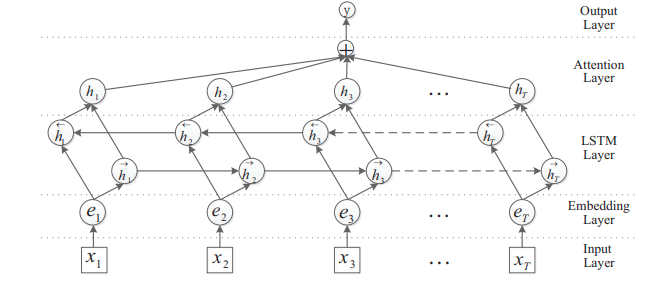

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import init
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

In [ ]:
class Att_BLSTM(nn.Module):
    def __init__(self, word_vec, class_num, max_len, word_dim, hidden_size, layers_num, dropout):
        super().__init__()
        self.word_vec = word_vec
        self.class_num = class_num

        self.max_len = max_len
        self.word_dim = word_dim
        self.hidden_size = hidden_size
        self.layers_num = layers_num
        self.dropout_value = dropout

        self.word_embedding = nn.Embedding.from_pretrained(
            embeddings=self.word_vec,
            freeze=False,
        )
        self.lstm = nn.LSTM(
            input_size=self.word_dim,
            hidden_size=self.hidden_size,
            num_layers=self.layers_num,
            bias=True,
            batch_first=True,
            dropout=self.dropout_value,
            bidirectional=True,
        )
        self.tanh = nn.Tanh()
        self.dropout = nn.Dropout(self.dropout_value)

        self.att_weight = nn.Parameter(torch.randn(1, self.hidden_size, 1))
        self.dense = nn.Linear(
            in_features=self.hidden_size,
            out_features=self.class_num,
            bias=True
        )
        init.xavier_normal_(self.dense.weight)
        init.constant_(self.dense.bias, 0.)

    def lstm_layer(self, x, mask):
        lengths = torch.sum(mask.gt(0), dim=-1)
        # Move lengths tensor to CPU
        lengths = lengths.cpu()
        x = pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        h, (_, _) = self.lstm(x)
        h, _ = pad_packed_sequence(h, batch_first=True, padding_value=0.0, total_length=self.max_len)
        h = h.view(-1, self.max_len, 2, self.hidden_size)
        h = torch.sum(h, dim=2)
        return h

    def attention_layer(self, h, mask):
        att_weight = self.att_weight.expand(mask.shape[0], -1, -1)
        att_score = torch.bmm(self.tanh(h), att_weight)
        mask = mask.unsqueeze(dim=-1)
        att_score = att_score.masked_fill(mask.eq(0), float('-inf'))
        att_weight = F.softmax(att_score, dim=1)
        reps = torch.bmm(h.transpose(1, 2), att_weight).squeeze(dim=-1)
        reps = self.tanh(reps)
        return reps

    def forward(self, data):
        token = data[:, 0, :].contiguous().view(-1, self.max_len)
        mask = data[:, 1, :].contiguous().view(-1, self.max_len)
        emb = self.word_embedding(token)
        emb = self.dropout(emb)
        h = self.lstm_layer(emb, mask)
        h = self.dropout(h)
        reps = self.attention_layer(h, mask)
        reps = self.dropout(reps)
        logits = self.dense(reps)
        return logits

In [ ]:
torch.device('cuda')

device(type='cuda')

In [ ]:
class_num = len(rel2id)

In [ ]:
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#device = 'cpu'
device=torch.device('cuda')
def count_parameters(model):
    s = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Number of parameteres {s:,}.')


model = Att_BLSTM(word_vec = word_vec, class_num = class_num, max_len = 100, word_dim = 300, hidden_size = 100, layers_num = 1, dropout = 0.5).to(device)

count_parameters(model)

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/rnn.py:83: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


Number of parameteres 120,325,116.


# Optimizer

In [ ]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss().to(device)

def optimiseur(model, lr=3e-4, eps=1e-6, weight_decay_rate=0.001, second_weight_decay_rate=0.0):
    param_optimizer = list(model.named_parameters())
    no_decay = ['bias', 'gamma', 'beta']
    optimizer_grouped_parameters = [
        {'params': [p for n, p in param_optimizer if not any(nd in n for nd in no_decay)],
            'weight_decay_rate': weight_decay_rate},
        {'params': [p for n, p in param_optimizer if any(nd in n for nd in no_decay)],
            'weight_decay_rate': second_weight_decay_rate}]
    return optim.Adam(
        optimizer_grouped_parameters,
        lr=lr,
        eps=eps
    )

# Metrics

In [ ]:
from sklearn.metrics import f1_score
import math


def f1_loss(predict_label, true_label, class_num=class_num):

    assert true_label.shape[0] == predict_label.shape[0]
    confusion_matrix = np.zeros(shape=[class_num, class_num], dtype=np.float32)
    xDIRx = np.zeros(shape=[class_num], dtype=np.float32)
    for i in range(true_label.shape[0]):
        true_idx = math.ceil(true_label[i]/2)
        predict_idx = math.ceil(predict_label[i]/2)
        if true_label[i] == predict_label[i]:
            confusion_matrix[predict_idx][true_idx] += 1
        else:
            if true_idx == predict_idx:
                xDIRx[predict_idx] += 1
            else:
                confusion_matrix[predict_idx][true_idx] += 1

    col_sum = np.sum(confusion_matrix, axis=0).reshape(-1)
    row_sum = np.sum(confusion_matrix, axis=1).reshape(-1)
    f1 = np.zeros(shape=[class_num], dtype=np.float32)

    for i in range(0, class_num):
        try:
            p = float(confusion_matrix[i][i]) / float(col_sum[i] + xDIRx[i])
            r = float(confusion_matrix[i][i]) / float(row_sum[i] + xDIRx[i])
            f1[i] = (2 * p * r / (p + r))
        except:
            pass
    actual_class = 0
    total_f1 = 0.0
    for i in range(1, class_num):
        if f1[i] > 0.0:
            actual_class += 1
            total_f1 += f1[i]
    try:
        macro_f1 = total_f1 / actual_class
    except:
        macro_f1 = 0.0
    return macro_f1

# Tranining

In [ ]:
def train_model(model, iterator, optimizer, criterion):
    predict_label = []
    true_label = []
    total_loss = 0.0
    acc = []
    for _, (data, label) in enumerate(iterator):
        model.train()
        data = data.to(device)
        label = label.to(device)

        optimizer.zero_grad()
        logits = model(data)
        loss = criterion(logits, label)

        loss.backward()
        nn.utils.clip_grad_value_(model.parameters(), clip_value=5)
        optimizer.step()
        total_loss += loss.item()

        _, pred = torch.max(logits, dim=1)
        pred = pred.cpu().detach().numpy().reshape((-1, 1))
        label = label.cpu().detach().numpy().reshape((-1, 1))
        predict_label.append(pred)
        true_label.append(label)

    predict_label = np.concatenate(predict_label, axis=0).reshape(-1).astype(np.int64)
    true_label = np.concatenate(true_label, axis=0).reshape(-1).astype(np.int64)
    eval_loss = total_loss / predict_label.shape[0]

    f1 = f1_loss(predict_label, true_label)

    return f1, eval_loss

def evaluate(model, iterator, criterion):

    predict_label = []
    true_label = []
    total_loss = 0.0

    with torch.no_grad():
        model.eval()
        for _, (data, label) in enumerate(iterator):
            data = data.to(device)
            label = label.to(device)

            logits = model(data)
            loss = criterion(logits, label)

            total_loss += loss.item()

            _, pred = torch.max(logits, dim=1)
            pred = pred.cpu().detach().numpy().reshape((-1, 1))
            label = label.cpu().detach().numpy().reshape((-1, 1))
            predict_label.append(pred)
            true_label.append(label)
    predict_label = np.concatenate(predict_label, axis=0).reshape(-1).astype(np.int64)
    true_label = np.concatenate(true_label, axis=0).reshape(-1).astype(np.int64)
    eval_loss = total_loss / predict_label.shape[0]

    f1 = f1_loss(predict_label, true_label)

    return f1, eval_loss, predict_label, true_label


In [ ]:
import time
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

def entrainement(model, optimizer, batch_size = 16, N_EPOCHS = 55):
    t_loss = []
    t_f1 = []
    v_loss = []
    v_f1 = []
    best_valid_loss = float('inf')

    for epoch in range(N_EPOCHS):


        start_time = time.time()

        train_f1, train_loss = train_model(model, train_loader, optimizer, criterion)
        t_loss.append(train_loss)
        t_f1.append(train_f1)

        valid_f1, valid_loss,_,_ = evaluate(model, valid_loader, criterion)
        v_loss.append(valid_loss)
        v_f1.append(valid_f1)
        end_time = time.time()

        epoch_mins, epoch_secs = epoch_time(start_time, end_time)

        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), my_path +'/BiLSTM_Att_DNRTI_RE_50.pt')


        print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
        print(f'\tTrain Loss: {train_loss:.3f} | Train F1 score: {train_f1*100:.2f}%')
        print(f'\t Val. Loss: {valid_loss:.3f} |  Val. F1 score: {valid_f1*100:.2f}%')
    return t_loss, v_loss, t_f1, v_f1

In [ ]:
N_EPOCHS = 55

t_l, v_l, t_f1, v_f1 = entrainement(model, optimiseur(model, lr = 1e-4, weight_decay_rate = 0.001), N_EPOCHS = N_EPOCHS)

Epoch: 01 | Epoch Time: 1m 40s
	Train Loss: 0.144 | Train F1 score: 11.50%
	 Val. Loss: 0.118 |  Val. F1 score: 33.07%
Epoch: 02 | Epoch Time: 1m 38s
	Train Loss: 0.119 | Train F1 score: 24.57%
	 Val. Loss: 0.095 |  Val. F1 score: 48.54%
Epoch: 03 | Epoch Time: 1m 38s
	Train Loss: 0.104 | Train F1 score: 32.30%
	 Val. Loss: 0.082 |  Val. F1 score: 37.87%
Epoch: 04 | Epoch Time: 1m 38s
	Train Loss: 0.094 | Train F1 score: 37.83%
	 Val. Loss: 0.074 |  Val. F1 score: 42.37%
Epoch: 05 | Epoch Time: 1m 38s
	Train Loss: 0.086 | Train F1 score: 42.93%
	 Val. Loss: 0.068 |  Val. F1 score: 50.47%
Epoch: 06 | Epoch Time: 1m 38s
	Train Loss: 0.080 | Train F1 score: 40.22%
	 Val. Loss: 0.062 |  Val. F1 score: 48.68%
Epoch: 07 | Epoch Time: 1m 38s
	Train Loss: 0.074 | Train F1 score: 38.47%
	 Val. Loss: 0.057 |  Val. F1 score: 52.88%
Epoch: 08 | Epoch Time: 1m 38s
	Train Loss: 0.070 | Train F1 score: 40.66%
	 Val. Loss: 0.054 |  Val. F1 score: 56.10%
Epoch: 09 | Epoch Time: 1m 38s
	Train Loss: 0.06

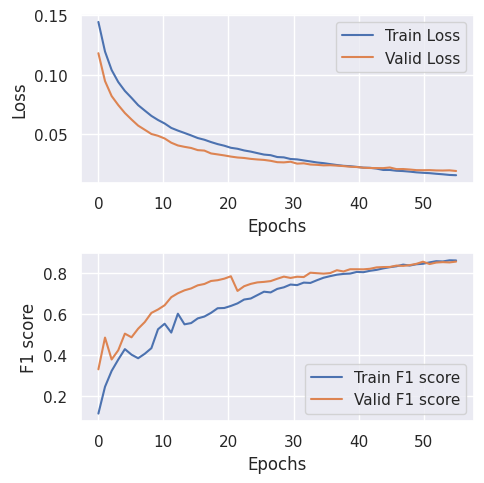

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
sns.set()

f = plt.figure(figsize=(5, 5))
gs = f.add_gridspec(2, 1)
plt.subplots_adjust(hspace=0.3)
x = np.linspace(0, N_EPOCHS,N_EPOCHS)
with sns.axes_style("darkgrid"):
    ax = f.add_subplot(gs[0])
    plt.plot(x,t_l, label='Train Loss')
    plt.plot(x,v_l, label='Valid Loss')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    #plt.title("Loss")
    plt.legend()

    ax = f.add_subplot(gs[1])
    plt.plot(x, t_f1, label='Train F1 score')
    plt.plot(x, v_f1, label='Valid F1 score')
    plt.xlabel("Epochs")
    plt.ylabel("F1 score")
   # plt.title("F1 score")
    plt.legend()


f.tight_layout()

Testing

In [ ]:
model.load_state_dict(torch.load(my_path + '/BiLSTM_Att_DNRTI_RE_50.pt'))
f1, eval_loss, preds, labels= evaluate(model, test_loader, criterion)

print(f'Test Loss: {eval_loss:.3f} |  Test F1 score: {f1*100:.2f}%')

Test Loss: 0.019 |  Test F1 score: 85.59%


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
predict =  preds
true =  labels

positive_labels = [i for i in range(len(rel2id)) if i != 0]
positive_names = [list(rel2id.keys())[list(rel2id.values()).index(str(i))] for i in range(len(rel2id)) if i != 0]
print(classification_report(
                y_true=true,
                y_pred=predict,
                labels=positive_labels,
                target_names=positive_names
            ))

# positive_labels = [int(i) for i in range(len(rel2id))]
# positive_names = [list(rel2id.keys())[list(rel2id.values()).index(str(i))] for i in positive_labels]

# print(classification_report(
#     y_true=true,
#     y_pred=predict,
#     labels=positive_labels,
#     target_names=positive_names
# ))


                          precision    recall  f1-score   support

          targets(e1,e2)       0.94      0.96      0.95      1606
             uses(e1,e2)       0.91      0.92      0.92      2256
       targetedBy(e1,e2)       0.96      0.94      0.95       702
hasAttackLocation(e1,e2)       0.99      0.97      0.98       762
      hasLocation(e1,e2)       0.99      0.97      0.98       428
   associatedWith(e1,e2)       0.84      0.81      0.83       911
    hasAttackTime(e1,e2)       0.99      0.98      0.99       331
       identifies(e1,e2)       0.91      0.95      0.93       463
         monitors(e1,e2)       0.89      0.87      0.88       164
           usedBy(e1,e2)       0.78      0.79      0.78       592
   affiliatedWith(e1,e2)       0.82      0.85      0.84       206
 hasVulnerability(e1,e2)       0.94      0.95      0.95       222
      monitoredBy(e1,e2)       0.97      0.83      0.89        46
     identifiedBy(e1,e2)       0.77      0.86      0.81        84
         

In [ ]:
import pandas as pd

confusion = confusion_matrix(true, predict)
l = positive_names

confusion_df =pd.DataFrame(confusion)

confusion_df.columns=l
s = pd.Series(l)
confusion_df = confusion_df.set_index([s])


confusion_df

,"targets(e1,e2)","uses(e1,e2)","targetedBy(e1,e2)","hasAttackLocation(e1,e2)","hasLocation(e1,e2)","associatedWith(e1,e2)","hasAttackTime(e1,e2)","identifies(e1,e2)","monitors(e1,e2)","usedBy(e1,e2)","affiliatedWith(e1,e2)","hasVulnerability(e1,e2)","monitoredBy(e1,e2)","identifiedBy(e1,e2)","contains(e1,e2)"
"targets(e1,e2)",1549,30,0,1,0,9,0,0,3,4,1,8,0,1,0
"uses(e1,e2)",42,2084,9,0,0,39,0,18,5,40,7,1,0,9,2
"targetedBy(e1,e2)",0,13,661,0,0,6,0,7,0,6,7,1,0,1,0
"hasAttackLocation(e1,e2)",9,2,0,741,3,2,0,0,0,0,4,0,0,1,0
"hasLocation(e1,e2)",0,0,0,2,417,0,0,4,4,0,1,0,0,0,0
"associatedWith(e1,e2)",14,71,9,4,1,738,0,1,0,62,9,0,0,1,1
"hasAttackTime(e1,e2)",2,2,0,0,0,1,324,0,0,0,0,0,0,2,0
"identifies(e1,e2)",0,13,1,0,0,0,0,438,5,1,5,0,0,0,0
"monitors(e1,e2)",4,6,0,0,0,0,0,11,143,0,0,0,0,0,0
"usedBy(e1,e2)",14,41,3,0,0,56,0,0,0,468,3,4,0,1,2


# References:
[Attention-Based Bidirectional Long Short-Term Memory Networks for
Relation Classification](https://www.aclweb.org/anthology/P16-2034.pdf)

Att-BLSTM-relation-extraction